<a href="https://www.kaggle.com/code/abeeralzebda/arabic-handwritten-digits?scriptVersionId=316426809" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mloey1/ahdd1/csvTrainImages 60k x 784.csv
/kaggle/input/datasets/mloey1/ahdd1/csvTestLabel 10k x 1.csv
/kaggle/input/datasets/mloey1/ahdd1/csvTrainLabel 60k x 1.csv
/kaggle/input/datasets/mloey1/ahdd1/Train + Test Matlab.mat
/kaggle/input/datasets/mloey1/ahdd1/csvTestImages 10k x 784.csv
/kaggle/input/datasets/mloey1/ahdd1/csvTrainImages 60k x 784/csvTrainImages 60k x 784.csv
/kaggle/input/datasets/mloey1/ahdd1/Arabic Handwritten Digits Dataset CSV/csvTrainImages 60k x 784.csv
/kaggle/input/datasets/mloey1/ahdd1/Arabic Handwritten Digits Dataset CSV/csvTestLabel 10k x 1.csv
/kaggle/input/datasets/mloey1/ahdd1/Arabic Handwritten Digits Dataset CSV/csvTrainLabel 60k x 1.csv
/kaggle/input/datasets/mloey1/ahdd1/Arabic Handwritten Digits Dataset CSV/csvTestImages 10k x 784.csv


# Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

2026-05-04 08:25:39.229281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777883139.396922      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777883139.444452      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777883139.840741      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777883139.840786      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777883139.840788      16 computation_placer.cc:177] computation placer alr

# Define X and Y

In [3]:
X=pd.read_csv("/kaggle/input/datasets/mloey1/ahdd1/csvTrainImages 60k x 784/csvTrainImages 60k x 784.csv")
X.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.486,0.487,0.488,0.489,0.490,0.491,0.492,0.493,0.494,0.495
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
y=pd.read_csv("/kaggle/input/datasets/mloey1/ahdd1/Arabic Handwritten Digits Dataset CSV/csvTrainLabel 60k x 1.csv")
y.head()

,0
0,1
1,2
2,3
3,4
4,5


In [5]:
print(X.shape, y.shape)

(59999, 784) (59999, 1)


## show one digit

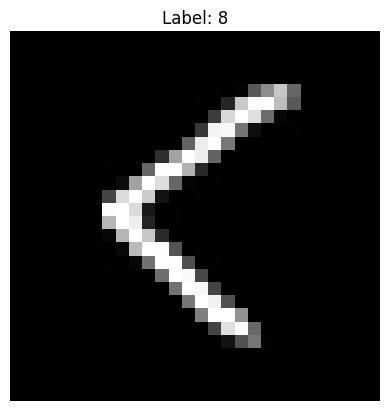

In [6]:
def show_digit(i):
    X_array = X.values if hasattr(X, 'values') else np.asarray(X)  # To NumPy (handles DataFrame/Series)
    y_array = y.iloc[:, 0].values if hasattr(y, 'iloc') else np.asarray(y)  # Extract 1D target from DataFrame
    
    plt.imshow(X_array[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {y_array[i]}')
    plt.axis('off')
    plt.show()

show_digit(887)

# Split data

In [7]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Build Model

In [8]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),   
    Dense(10, activation='softmax')                   ])

model.summary()

2026-05-04 08:26:03.445543: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile model
model.compile(
    loss='sparse_categorical_crossentropy',  # for multi-class
    optimizer='adam',
    metrics=['accuracy']
)


# Train Model

In [10]:

history = model.fit(X_train, y_train, epochs=40, validation_data=(X_test, y_test))


Epoch 1/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9028 - loss: 5.4662 - val_accuracy: 0.9638 - val_loss: 0.5260
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9695 - loss: 0.3994 - val_accuracy: 0.9699 - val_loss: 0.2721
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9766 - loss: 0.1816 - val_accuracy: 0.9667 - val_loss: 0.2748
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9780 - loss: 0.1387 - val_accuracy: 0.9634 - val_loss: 0.2833
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9758 - loss: 0.1434 - val_accuracy: 0.9688 - val_loss: 0.2058
Epoch 6/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9792 - loss: 0.1130 - val_accuracy: 0.9755 - val_loss: 0.1426
Epoch 7/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9822 - loss: 0.1047 - val_accuracy: 0.9727 - val_loss: 0.1890
Epoch 8/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9805 - loss: 0.1255 - 

In [11]:
pred = model.predict(X_test[:9])
print('Predicted:', np.argmax(pred, axis=1))
print('True:', y_test[:9])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted: [1 2 1 6 0 0 2 6 7]
True:        0
12628  9
51841  2
47430  1
8525   6
8279   0
15759  0
16861  2
15125  6
9366   7


# Prediction on New Data 

In [12]:
X_test2=pd.read_csv('/kaggle/input/datasets/mloey1/ahdd1/Arabic Handwritten Digits Dataset CSV/csvTestImages 10k x 784.csv')
X_test2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Columns: 784 entries, 0 to 0.547
dtypes: int64(784)
memory usage: 59.8 MB


In [13]:
Y_test2=pd.read_csv('/kaggle/input/datasets/mloey1/ahdd1/Arabic Handwritten Digits Dataset CSV/csvTestLabel 10k x 1.csv')
Y_test2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       9999 non-null   int64
dtypes: int64(1)
memory usage: 78.2 KB


In [14]:

pred2 = model.predict(X_test2)
print('Predicted:', np.argmax(pred2, axis=1))
print('True:', Y_test2[8900:8909])


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted: [1 2 3 ... 7 8 9]
True:       0
8900  1
8901  2
8902  3
8903  4
8904  5
8905  6
8906  7
8907  8
8908  9


In [15]:
predictions = np.argmax(pred2, axis=1)
pred_df = pd.DataFrame({'prediction': predictions})

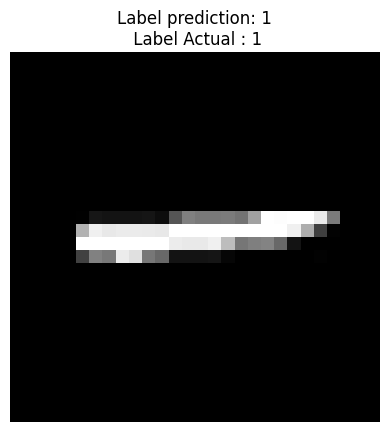

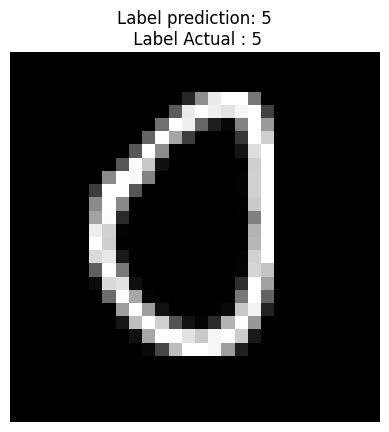

In [16]:
def show_digit(i):
    X_array = X_test2.values if hasattr(X_test2, 'values') else np.asarray(X_test2)  
    y_array = Y_test2.iloc[:, 0].values if hasattr(Y_test2, 'iloc') else np.asarray(Y_test2)  
    pred2=pred_df.iloc[:, 0].values if hasattr(pred_df, 'iloc') else np.asarray(pred_df) 
    plt.imshow(X_array[i].reshape(28, 28), cmap='gray')
    
    plt.title(f'Label prediction: {pred2[i]}\n Label Actual : {y_array[i]}')
  
    plt.axis('off')
    plt.show()

show_digit(0)
show_digit(174)